In [51]:
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import numpy.random as rd
import sklearn.datasets as dt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, precision_recall_curve, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression #Classificador
from sklearn.neighbors import KNeighborsClassifier
import sklearn.preprocessing as pp
import numpy.random as rd
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
import pickle
import scipy.spatial.distance as spd
from sklearn.svm import SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import scipy.io.wavfile as wav
from sklearn.linear_model import LinearRegression 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge, Lasso
import scipy.io.wavfile as wav

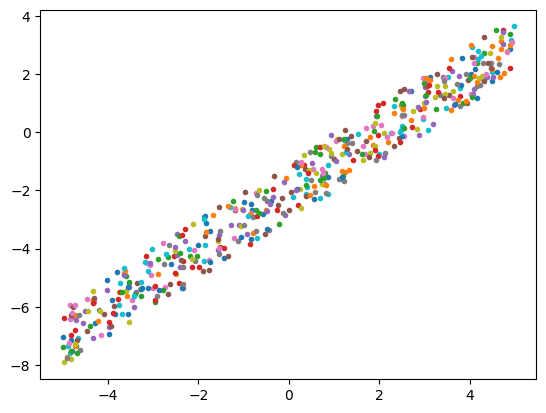

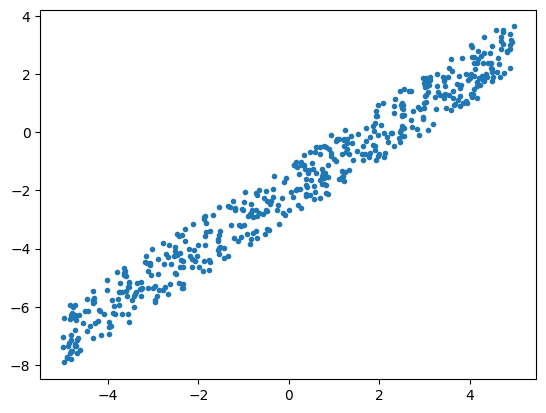

(500,)


In [21]:
D= pickle.load(open('RegressData001.p', 'rb'))

#squeeze elimina dimensoes redundantes
x= D['x']
y= D['y']
plt.plot(x, y, '.'), plt.show()

x= x.squeeze()
y= y.squeeze()
plt.plot(x, y, '.'), plt.show()

print(x.shape)

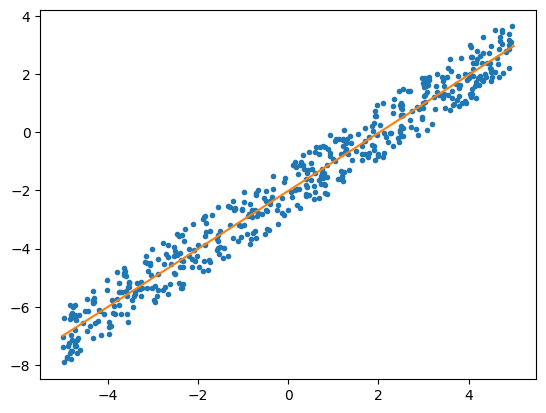

([<matplotlib.lines.Line2D at 0x285ac1a7a50>],
 None)

In [25]:
# ^y= w0 + w1

X= np.vstack((np.ones(500), x)) #Colocar as coordenadas homogéneas
Rx= np.dot(X, X.T)
rxy= np.dot(X, y.T)

w= np.dot(np.linalg.pinv(Rx), rxy)

t= np.linspace(-5, 5, 100)
T= np.vstack((np.ones(100), t)) #Acrescentar uma coordenada homogénea
yt= np.dot(w, T)
plt.plot(x, y, '.'), plt.plot(t, yt), plt.show()


In [ ]:
D2= pickle.load(open('RegressData002.p', 'rb'))

#squeeze elimina dimensoes redundantes
x2= D2['x']
y2= D2['y']
plt.plot(x2, y2, '.'), plt.show()

x2= x2.squeeze()
y2= y2.squeeze()
plt.plot(x2, y2, '.'), plt.show()

print(x2.shape)

In [23]:
X2= np.vstack((np.ones(1500), x2, x2**2, x2**3))
Rx2= np.dot(X2, X2.T)
rxy2= np.dot(X2, y2.T)

w2= np.dot(np.linalg.pinv(Rx2), rxy2) #coeficietes dos x's para cada dimensão
w2

array([ 2.01160905, -0.98245165, -0.51315283,  0.11294984])

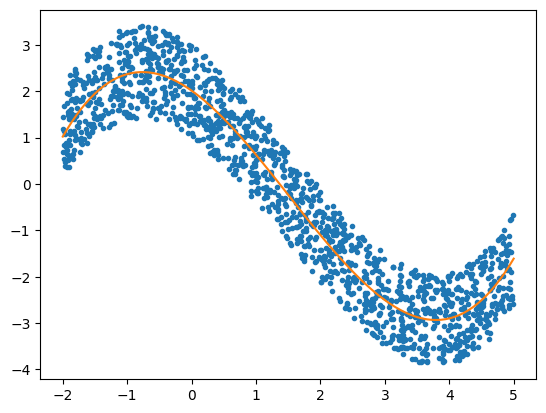

([<matplotlib.lines.Line2D at 0x285acbc7050>],
 None)

In [24]:
t2= np.linspace(-2, 5, 100)
T2= np.vstack((np.ones(100), t2, t2**2, t2**3)) #Acrescentar uma coordenada homogénea
yt2= np.dot(w2, T2)
plt.plot(x2, y2, '.'), plt.plot(t2, yt2), plt.show()

In [31]:
D3= dt.load_diabetes()

X3= D3.data
y3= D3.target # variável contínua que indica quão a doença está avançada numa pessoa

X1, X2, y1, y2= train_test_split(X3, y3, test_size= 1/3, random_state=42)

Xa= np.vstack((np.ones(294), X1.T))
Rx= np.dot(Xa, Xa.T)
rxy= np.dot(Xa, y1)
w1= np.dot(np.linalg.pinv(Rx), rxy)

w1


array([ 150.47050072,   32.14114954, -243.77454184,  560.321881  ,
        406.14449765, -715.97724955,  394.56874273,    9.54562174,
        172.52820314,  626.90587608,  -21.05781046])

In [34]:
lr= LinearRegression().fit(X1, y1)
lr.coef_

array([  32.14114954, -243.77454184,  560.321881  ,  406.14449765,
       -715.97724955,  394.56874273,    9.54562174,  172.52820314,
        626.90587608,  -21.05781046])

In [35]:
lr.intercept_

np.float64(150.47050071830287)

In [36]:
m1= np.mean(y1)
y1e= np.dot(w1, Xa)
Stot= np.mean((y1-m1)**2)
Se= np.mean((y1-y1e)**2)
1-Se/Stot

np.float64(0.5093570977346067)

In [37]:
lr.score(X1, y1)

0.5093570977346067

In [38]:
lr.score(X2, y2) 

0.5117088779840541

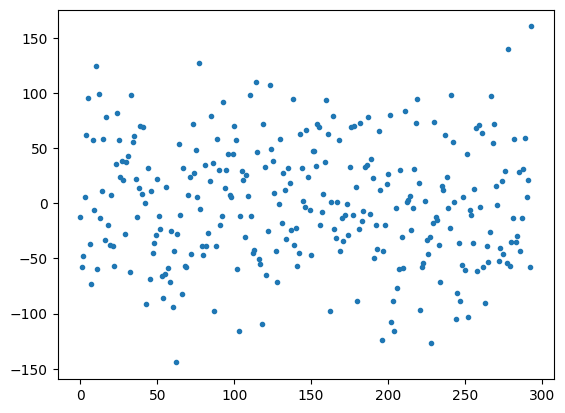

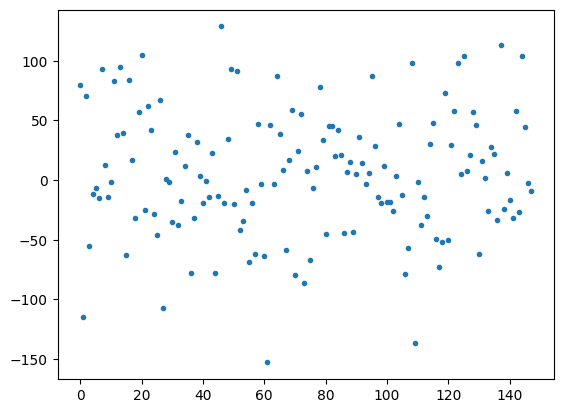

([<matplotlib.lines.Line2D at 0x285a9f2bcd0>], None)

In [40]:
y1e= lr.predict(X1)
y2e= lr.predict(X2)

plt.plot(y1-y1e, '.'), plt.show() #Visualizar o erro, o erro vvaria tanto como o y (300), o que não é bom sinal
plt.plot(y2-y2e, '.'), plt.show()

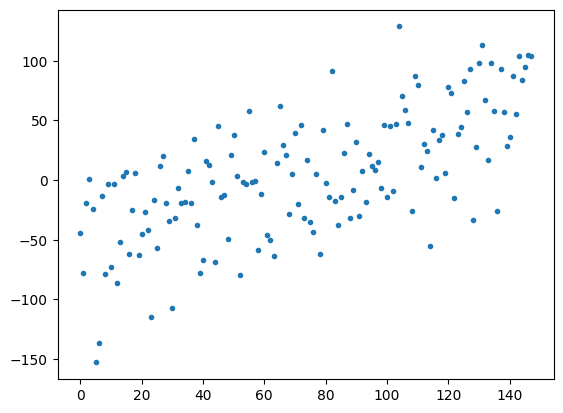

([<matplotlib.lines.Line2D at 0x285a9b362d0>], None)

In [41]:
idx= np.argsort(y2) #ordenar y2
y2= y2[idx]
y2e= y2e[idx]
X2= X2[idx,:]
plt.plot(y2-y2e, '.'), plt.show() # o erro é maior nas classes superiores

In [47]:
a= np.arange(1, 11)
np.sum(a)

xtmp= np.round(np.random.rand(10,3),2)
pf= PolynomialFeatures(2).fit(xtmp)
xtmp2= pf.transform(xtmp)

#x1, x2, x3, x1^2, x2^2, x3^2, x1x2, x1x3, x2x3 - 9 (acrescenta 1 por causa das coordenadas homogeneas)
# pf= PolynimialFeatures(2, include_bias= False).fit(xtmp)

pf= PolynomialFeatures(degree=2, include_bias=False).fit(X1)
X1p= pf.transform(X1)
X2p= pf.transform(X2) #Shape com 65 porque x1-x10= 10, X1^2-X10^2= 10, +9, +8, ...., +1

lr= LinearRegression().fit(X1p,y1)
lr.score(X1p, y1)
lr.score(X2p, y2) # Pior para o teste 

0.4619241132371833

In [49]:
#Usar regularização

lr= Lasso().fit(X1p, y1)
lr.score(X2p, y2)
lr.coef_

array([  0.        ,  -0.        , 427.94461569,  71.68246792,
         0.        ,   0.        ,  -0.        ,   0.        ,
       177.84394105,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,  -0.        ,  -0.        ,
        -0.        ,   0.        ,   0.        ,   0.        ,
        -0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,  -0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,  -0.        ,
        -0.        ,  -0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        -0.        ,   0.        ,   0.        ,   0.        ,
         0.        ,   0.        ,  -0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.        ,
        -0.        ,  -0.        ,  -0.        ,  -0.        ,
         0.        ,  -0.        ,  -0.        ,   0.        ,
         0.        ,   0.        ,   0.        ,   0.  

In [50]:
lr= Ridge().fit(X1p, y1)
lr.score(X2p, y2)
lr.coef_

array([ 4.04135991e+01, -6.15582052e+01,  2.73016273e+02,  1.97259232e+02,
       -1.53830924e+00, -1.89130172e+01, -1.42844995e+02,  1.07222845e+02,
        1.95002048e+02,  8.41734451e+01,  2.97032027e+00,  5.13083204e+00,
       -1.17127522e-01,  3.95312708e+00, -1.84440947e+00, -3.19205465e+00,
       -2.38761174e+00,  1.71266170e+00,  3.64188745e+00,  2.78956781e+00,
       -3.71718129e-01,  2.84175458e+00,  4.26624664e+00,  1.25353747e+00,
       -1.99905885e-02, -4.20256023e-01,  1.83558323e+00,  3.32218362e+00,
        1.83092884e+00,  1.49262897e+01,  8.47971278e+00, -3.51247457e+00,
       -3.48286142e+00, -4.75334213e+00,  2.77512589e+00,  3.61187915e+00,
        6.29402198e+00,  7.92030174e+00,  1.86320965e+00,  4.35223626e-01,
       -1.11983453e+00,  1.81244431e+00,  4.28226700e+00,  3.58992092e+00,
        1.17616145e+00, -2.53668425e-02,  1.74879247e+00, -1.17890933e+00,
       -4.53510316e-01,  1.25898642e+00, -9.53375943e-01,  2.78033437e+00,
       -2.35835836e+00, -

In [52]:
fs, x= wav.read('Violin.arco.ff.sulG.Gb4.mono.wav')
fs #freq amostragem

22050

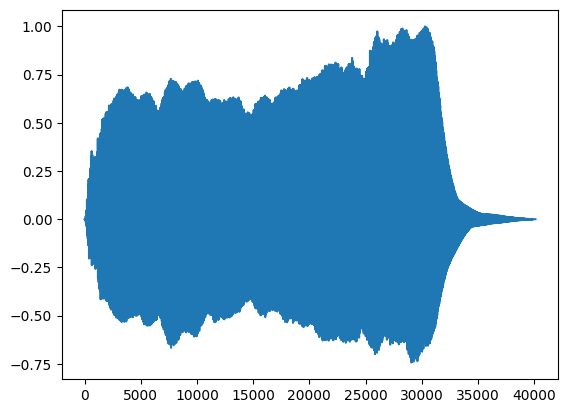

In [53]:
x.dtype

#normalizar para 1 e -1
x= x/2.**15
plt.plot(x)
plt.show()

In [ ]:
x= x[:10000]
ax= plt.figure().add_subplot(projection='3d')
ax.plot(x[:-2], x[1, :-1], )